In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import contourpy
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter
import numpy as np
from _FigureJiazeHelper import *
from _DetectabilityWithMeta import *
from _CommunityDetect import *
from EXPERIMENT_MinoritySameDegree import *
from scipy.optimize import linear_sum_assignment

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=10)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 10  # 'large'
plt.rcParams['lines.markersize'] = 12
plt.rcParams['axes.linewidth'] = 0.5

# %matplotlib notebook
%config InlineBackend.figure_format = 'retina'

# BP with homo degree


In [3]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 3
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "2ndType_3or2decimal"
checkSNR = False
Type = 2
fileID = 'amiExp24.6.1' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"

add_additionId = "2ndType_3or2decimal_10more"
add_fileId = 'amiExp24.6.3' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{add_additionId}'
add_loadpath = ["./result/detectabilityWithMeta/" + add_fileId + ".txt"]
exclude_rho = [0.4, 0.42, 0.44, 0.46, 0.48]
exclude_z = [0.00366, 0.00381, 0.00395, 0.0041]
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, add_paths=add_loadpath, exclude_rho=exclude_rho, exclude_z=exclude_z)
print(np.unique(plot_rhos), np.unique(plot_zs), np.size(plot_zs))

Additional result adding...
[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38] [0.00015 0.00029 0.00044 0.00059 0.00073 0.00088 0.00103 0.00117 0.00132
 0.00146 0.00161 0.00176 0.0019  0.00205 0.0022  0.00234 0.00249 0.00264
 0.00278 0.00293 0.00308 0.00322 0.00337 0.00351] 456


In [6]:
rhos = np.unique(plot_rhos)
deltas = np.unique(plot_zs)
lambdas_reduce_B = np.zeros((np.size(deltas) * np.size(rhos), 3))
lambdas_reduce_S = np.zeros((np.size(deltas) * np.size(rhos), 4))
expi = 0
for rho in rhos:
    for delta in deltas:
        # Construct 2nd type ps
        pout1 = d / n - (1 / (1 - 2 * rho)) * ((1 - rho) ** 2 / Z_b - rho ** 2 / Z_s) * delta
        pin = pout1 + delta
        pout2 = 2 * d / n - ((1 - rho) / Z_b + rho / Z_s) * delta - pout1
        pout1 = 0 if abs(pout1) < 1e-10 else pout1
        pout2 = 0 if abs(pout2) < 1e-10 else pout2
        pin = 0 if abs(pin) < 1e-10 else pin
        q_B = Z_s + 1
        ps_B = np.zeros((q_B, q_B))
        ps_B = np.array([[pin, pout1, pout2], [pout1, pin, pout2], [pout2, pout2, (pin+(3-1)*pout1)/3]])
        if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
            # print(f'{rho} {delta}')
            lambdas_reduce_B[expi, :] = [-1, 1, 1]
        else:
            P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / 1] * 1)
            Q = n * ps_B
            lambdas_reduce_B[expi, :] = MetaSBM.get_lambdas_general(P, Q)
            # print(f'rho={rho}, delta={delta}, snr of reduce majority communities into 1 community={lambdas_reduce_B[expi, 1]**2/lambdas_reduce_B[expi, 0]}')
        q_S = Z_b + 1
        ps_S = np.zeros((q_S, q_S))
        ps_S = np.array([[(pin+(2-1)*pout1)/2, pout2, pout2, pout2], [pout2, pin, pout1, pout1], [pout2, pout1, pin, pout1], [pout2, pout1, pout1, pin]])
        if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
            # print(f'{rho} {delta}')
            lambdas_reduce_S[expi, :] = [-1, 1, 1, 1]
        else:
            P = np.diag([rho / 1] * 1 + [(1 - rho) / Z_b] * Z_b)
            Q = n * ps_S
            lambdas_reduce_S[expi, :] = MetaSBM.get_lambdas_general(P, Q)
            # print(f'rho={rho}, delta={delta}, snr of reduce majority communities into 1 community={lambdas_reduce_B[expi, 1]**2/lambdas_reduce_B[expi, 0]}')
        expi += 1

minz=0, maxz=0.9376330000000002, cticks=[0. 1.], clabel=['0.0', '1.0']
minz=1, maxz=5.15, cticks=[0.         0.24127907 0.48255814 0.72383721 0.96511628], clabel=['1.0', '2.0', '3.0', '4.0', '5.0']


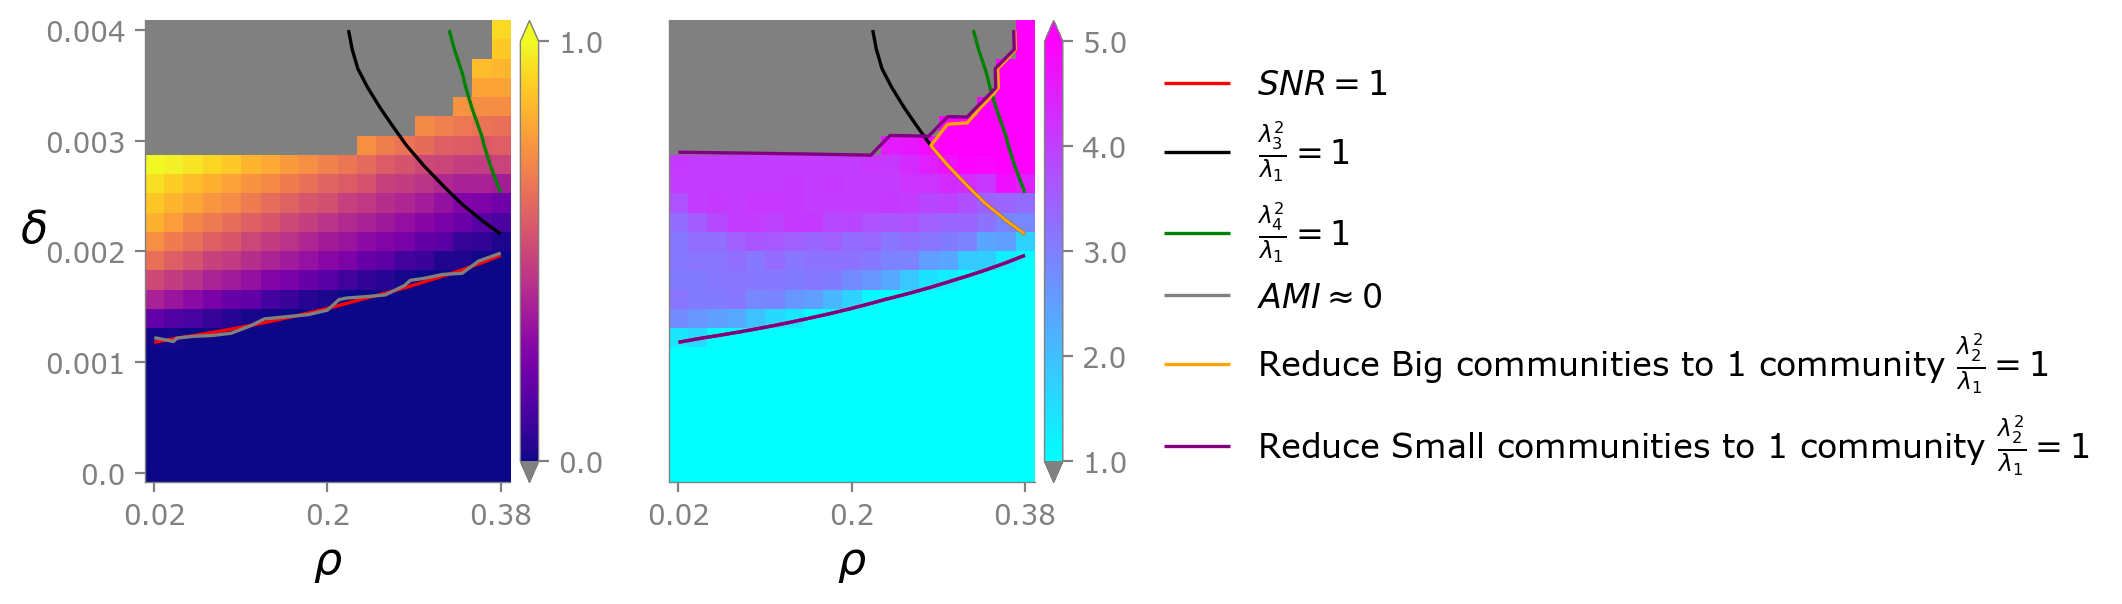

In [9]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
# handels += contour_data(plot_subami, ax, levels=[1e-3], fmt={1e-3: r'AMI$\simeq$0'}, color='gray', inline=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, vmin=0, vmax=1, ytickprecision=3)
x = plot_rhos
y = plot_zs
z = sub_ami
_x = np.sort(np.unique(x))
_y = np.sort(np.unique(y))
for i, zi in enumerate(z):
    if z[i] == -1:
        i_x = np.where(_x == x[i])[0]
        i_y = np.where(_y == y[i])[0]
#         ax.add_patch(mpl.patches.Rectangle((i_x-.5, i_y-.5), 1, 1, hatch='///////', fill=True, snap=False, color="gray", zorder=2))
        contour_subami[i_y, i_x] = 1
handels += contour_data(contour_subami, ax, levels=[1e-2], fmt={1e-2: r'AMI$\simeq$0'}, color='gray', inline=False)
        
row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, cmap=cmap, 
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

plot_reduceB_snr = color_imshow_2d(plot_rhos, plot_zs, lambdas_reduce_B[:, 1]**2/lambdas_reduce_B[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_reduceB_snr, ax, levels=[1], fmt={1: r'$SNR_{reduceB}=1$'}, color='orange', inline=False)

plot_reduceS_snr = color_imshow_2d(plot_rhos, plot_zs, lambdas_reduce_S[:, 1]**2/lambdas_reduce_S[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_reduceS_snr, ax, levels=[1], fmt={1: r'$SNR_{reduceS}=1$'}, color='purple', inline=False)

# contour_data(color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**(3/2)*abs(lambdas[:, 2])**(1/2)/lambdas[:, 0], z_center=1, return_gridz=True),
#              ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='yellow', inline=False)

# contour_data(color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**(3/2)*abs(lambdas[:, 3])**(1/2)/lambdas[:, 0], z_center=1, return_gridz=True),
#              ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='blue', inline=False)
# for i, zi in enumerate(z):
#     if z[i] == -1:
#         i_x = np.where(_x == x[i])[0]
#         i_y = np.where(_y == y[i])[0]
#         ax.add_patch(mpl.patches.Rectangle((i_x-.5, i_y-.5), 1, 1, hatch='///////', fill=True, snap=False, color="gray", zorder=2))

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$', r'$AMI\approx0$', 
                           r'Reduce Big communities to 1 community $\frac{\lambda_2^2}{\lambda_1}=1$',
                           r'Reduce Small communities to 1 community $\frac{\lambda_2^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BP_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + "_v1.pdf"
# # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

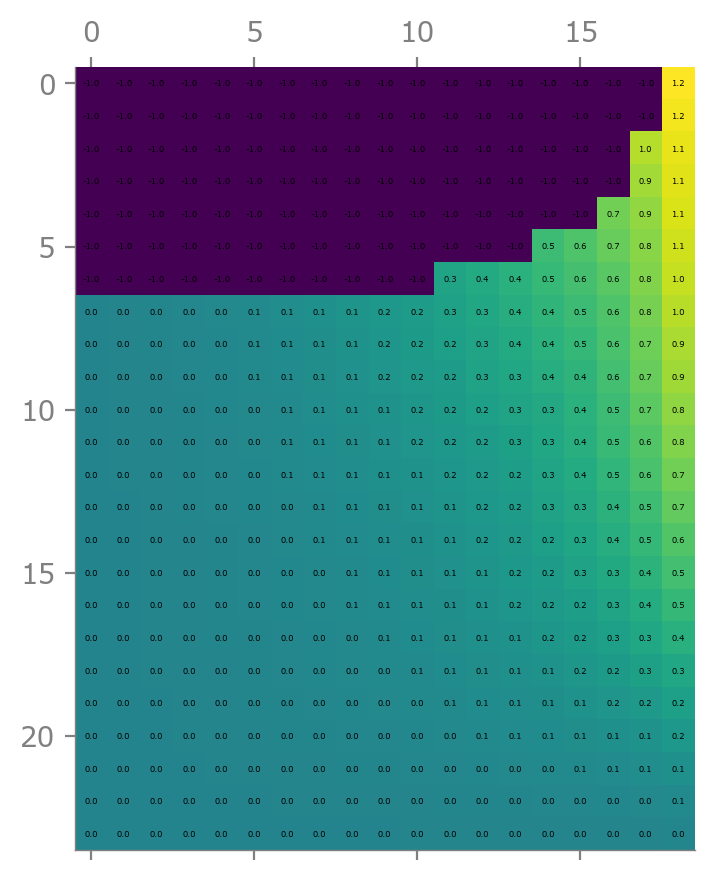

In [22]:
show_snr = np.flip(plot_reducesnr, axis=0)
plt.matshow(show_snr)
shape = np.shape(show_snr)
for i in range(shape[0]):
    for j in range(shape[1]):
        c = np.around(show_snr[i,j], 1)
        plt.text(j, i, str(c), va='center', ha='center', fontsize=3)

minz=0, maxz=0.9376330000000002, cticks=[0. 1.], clabel=['0.0', '1.0']
minz=1, maxz=5.15, cticks=[0.         0.24127907 0.48255814 0.72383721 0.96511628], clabel=['1.0', '2.0', '3.0', '4.0', '5.0']


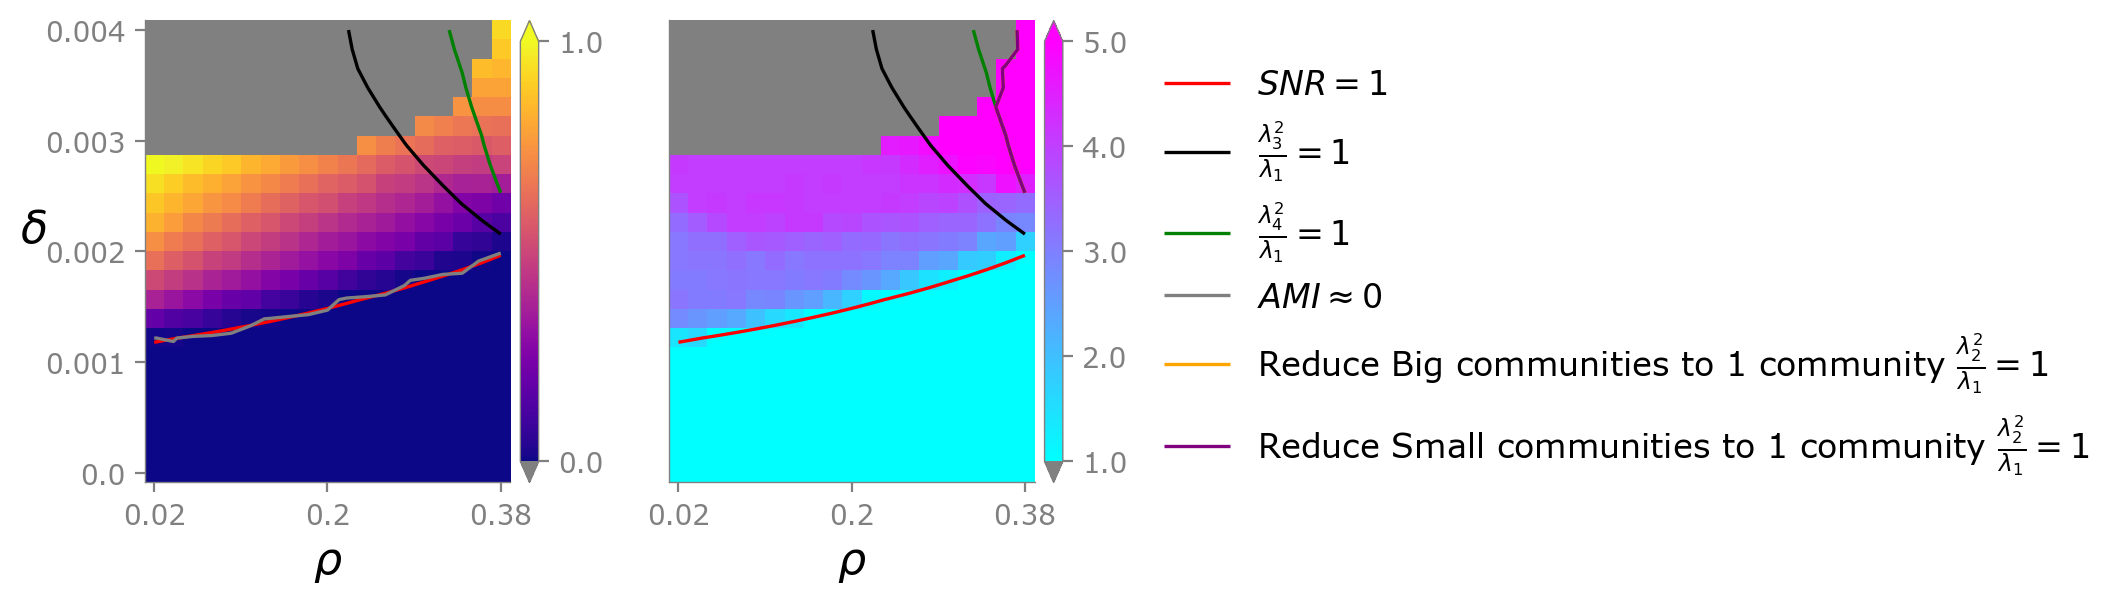

In [11]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
# handels += contour_data(plot_subami, ax, levels=[1e-3], fmt={1e-3: r'AMI$\simeq$0'}, color='gray', inline=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, vmin=0, vmax=1, ytickprecision=3)
x = plot_rhos
y = plot_zs
z = sub_ami
_x = np.sort(np.unique(x))
_y = np.sort(np.unique(y))
for i, zi in enumerate(z):
    if z[i] == -1:
        i_x = np.where(_x == x[i])[0]
        i_y = np.where(_y == y[i])[0]
#         ax.add_patch(mpl.patches.Rectangle((i_x-.5, i_y-.5), 1, 1, hatch='///////', fill=True, snap=False, color="gray", zorder=2))
        contour_subami[i_y, i_x] = 1
handels += contour_data(contour_subami, ax, levels=[1e-2], fmt={1e-2: r'AMI$\simeq$0'}, color='gray', inline=False)
        
row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, cmap=cmap, 
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

plot_reduceB_snr = color_imshow_2d(plot_rhos, plot_zs, lambdas_reduce_B[:, 2]**2/lambdas_reduce_B[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_reduceB_snr, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}_{reduceB}=1$'}, color='orange', inline=False)

plot_reduceS_snr = color_imshow_2d(plot_rhos, plot_zs, lambdas_reduce_S[:, 3]**2/lambdas_reduce_S[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_reduceS_snr, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}_{reduceS}=1$'}, color='purple', inline=False)

# contour_data(color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**(3/2)*abs(lambdas[:, 2])**(1/2)/lambdas[:, 0], z_center=1, return_gridz=True),
#              ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='yellow', inline=False)

# contour_data(color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**(3/2)*abs(lambdas[:, 3])**(1/2)/lambdas[:, 0], z_center=1, return_gridz=True),
#              ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='blue', inline=False)
# for i, zi in enumerate(z):
#     if z[i] == -1:
#         i_x = np.where(_x == x[i])[0]
#         i_y = np.where(_y == y[i])[0]
#         ax.add_patch(mpl.patches.Rectangle((i_x-.5, i_y-.5), 1, 1, hatch='///////', fill=True, snap=False, color="gray", zorder=2))

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$', r'$AMI\approx0$', 
                           r'Reduce Big communities to 1 community $\frac{\lambda_2^2}{\lambda_1}=1$',
                           r'Reduce Small communities to 1 community $\frac{\lambda_2^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BP_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + "_v1.pdf"
# # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [9]:
rhos = np.unique(plot_rhos)
deltas = np.unique(plot_zs)
lambdas_reduce = np.zeros((np.size(deltas) * np.size(rhos), 3))
expi = 0
for rho in rhos:
    for delta in deltas:
        # Construct 2nd type ps
        pout1 = d / n - (1 / (1 - 2 * rho)) * ((1 - rho) ** 2 / Z_b - rho ** 2 / Z_s) * delta
        pin = pout1 + delta
        pout2 = 2 * d / n - ((1 - rho) / Z_b + rho / Z_s) * delta - pout1
        pout1 = 0 if abs(pout1) < 1e-10 else pout1
        pout2 = 0 if abs(pout2) < 1e-10 else pout2
        pin = 0 if abs(pin) < 1e-10 else pin
        q = Z_s + 1
        ps = np.array([[pin, pout1, pout2], [pout1, pin, pout2], [pout2, pout2, pin]])
        if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
            # print(f'{rho} {delta}')
            lambdas_reduce[expi, :] = [-1, 1, 1]
        else:
            P = np.diag([rho / Z_s] * Z_s + [(1 - rho)] * 1)
            Q = n * ps
            lambdas_reduce[expi, :] = MetaSBM.get_lambdas_general(P, Q)
            print(f'rho={rho}, delta={delta}, snr of reduce majority communities into 1 community={lambdas_reduce_B[expi, 1]**2/lambdas_reduce_B[expi, 0]}')
        expi += 1

minz=0, maxz=0.9376330000000002, cticks=[0. 1.], clabel=['0.0', '1.0']
minz=1, maxz=5.15, cticks=[0.         0.24127907 0.48255814 0.72383721 0.96511628], clabel=['1.0', '2.0', '3.0', '4.0', '5.0']


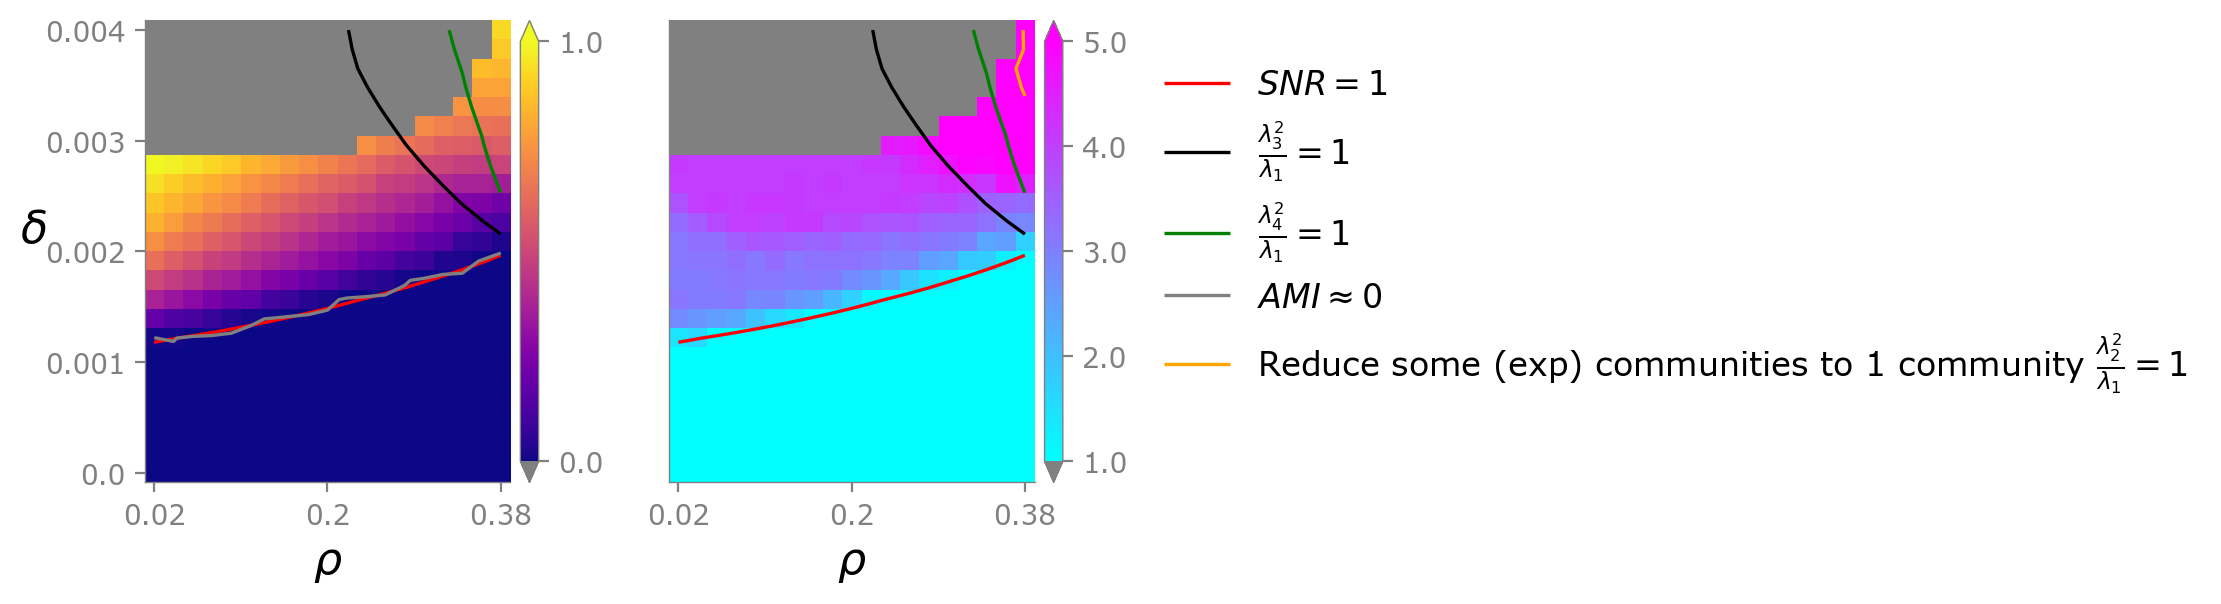

In [10]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6.2, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
# handels += contour_data(plot_subami, ax, levels=[1e-3], fmt={1e-3: r'AMI$\simeq$0'}, color='gray', inline=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, vmin=0, vmax=1, ytickprecision=3)
x = plot_rhos
y = plot_zs
z = sub_ami
_x = np.sort(np.unique(x))
_y = np.sort(np.unique(y))
for i, zi in enumerate(z):
    if z[i] == -1:
        i_x = np.where(_x == x[i])[0]
        i_y = np.where(_y == y[i])[0]
#         ax.add_patch(mpl.patches.Rectangle((i_x-.5, i_y-.5), 1, 1, hatch='///////', fill=True, snap=False, color="gray", zorder=2))
        contour_subami[i_y, i_x] = 1
handels += contour_data(contour_subami, ax, levels=[1e-2], fmt={1e-2: r'AMI$\simeq$0'}, color='gray', inline=False)
        
row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, cmap=cmap, 
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

plot_reduce_snr = color_imshow_2d(plot_rhos, plot_zs, lambdas_reduce[:, 2]**2/lambdas_reduce[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_reduce_snr, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}_{reduce}=1$'}, color='orange', inline=False)

# contour_data(color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**(3/2)*abs(lambdas[:, 2])**(1/2)/lambdas[:, 0], z_center=1, return_gridz=True),
#              ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='yellow', inline=False)

# contour_data(color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**(3/2)*abs(lambdas[:, 3])**(1/2)/lambdas[:, 0], z_center=1, return_gridz=True),
#              ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='blue', inline=False)
# for i, zi in enumerate(z):
#     if z[i] == -1:
#         i_x = np.where(_x == x[i])[0]
#         i_y = np.where(_y == y[i])[0]
#         ax.add_patch(mpl.patches.Rectangle((i_x-.5, i_y-.5), 1, 1, hatch='///////', fill=True, snap=False, color="gray", zorder=2))

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$', r'$AMI\approx0$', 
                           r'Reduce some (exp) communities to 1 community $\frac{\lambda_2^2}{\lambda_1}=1$',], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BP_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + "_v1.pdf"
# # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# Consistent d

In [43]:
n = 6000
d = 5
Z_s = 3
Z_b = 2
q = Z_s + Z_b
rhos = np.setdiff1d(np.around(np.linspace(0, 1, 504), 2), np.array([0, 0.5, 1]))
Type = 2
min_delta, max_delta = None, None
for r in rhos:
    for delta in np.setdiff1d(np.around(np.linspace(-1, 1, 10000), 6), np.array([])):
        _, pin, pout1, pout2 = get_ps(n, d, Z_s, Z_b, r, delta, Type)
        if 0 <= pin <= 1 and 0 <= pout1 <= 1 and 0 <= pout2 <= 1:
            min_delta = delta if min_delta is None or delta < min_delta else min_delta
            max_delta = delta if max_delta is None or delta > max_delta else max_delta
            # print(f"rho={r}, delta={delta}, pin={pin}, pout1={pout1}, pout2={pout2}")
        else:
            pass
# min_delta = 0  # only consider assortative case
deltas = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, 502), 5), np.array([0]))
print(rhos, deltas)

[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42
 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.51 0.52 0.53 0.54 0.55 0.56 0.57
 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71
 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85
 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99] [-2.70e-03 -2.69e-03 -2.67e-03 -2.66e-03 -2.65e-03 -2.63e-03 -2.62e-03
 -2.60e-03 -2.59e-03 -2.58e-03 -2.56e-03 -2.55e-03 -2.54e-03 -2.52e-03
 -2.51e-03 -2.50e-03 -2.48e-03 -2.47e-03 -2.46e-03 -2.44e-03 -2.43e-03
 -2.41e-03 -2.40e-03 -2.39e-03 -2.37e-03 -2.36e-03 -2.35e-03 -2.33e-03
 -2.32e-03 -2.31e-03 -2.29e-03 -2.28e-03 -2.27e-03 -2.25e-03 -2.24e-03
 -2.22e-03 -2.21e-03 -2.20e-03 -2.18e-03 -2.17e-03 -2.16e-03 -2.14e-03
 -2.13e-03 -2.12e-03 -2.10e-03 -2.09e-03 -2.08e-03 -2.06e-03 -2.05e-03
 -2.0

In [41]:
lambdas = np.zeros((np.size(deltas) * np.size(rhos), 4))
max_snr = 0
expi = 0
for rho in rhos:
    for delta in deltas:
        ps, pin, pout1, pout2 = get_ps(n, d, Z_s, Z_b, rho, delta, Type)
        if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
            # for delta let pin pout not in [0, 1], return (-1,0)
            # print(f"rho={rho}, delta={delta}, pin={pin}, pout1={pout1}, pout2={pout2}, wrong")
            lambdas[expi, :] = [1, np.inf, np.inf, np.inf]
        else:
            P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / Z_b] * Z_b)
            Q = n * ps
            lambdas[expi, :] = MetaSBM.get_lambdas_homoDegree(n, d, Z_s, Z_b, rho, delta, Type=Type)
            snr = lambdas[expi, 1]**2/lambdas[expi, 0]
            if snr is not np.inf and snr>max_snr:
                max_snr = snr
            # print(f'rho={rho}, delta={delta}, lambdas_PQ={lambdas}')
        expi += 1

inf
minz=0, maxz=4.99810018050001, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['0', '1', '2', '5']


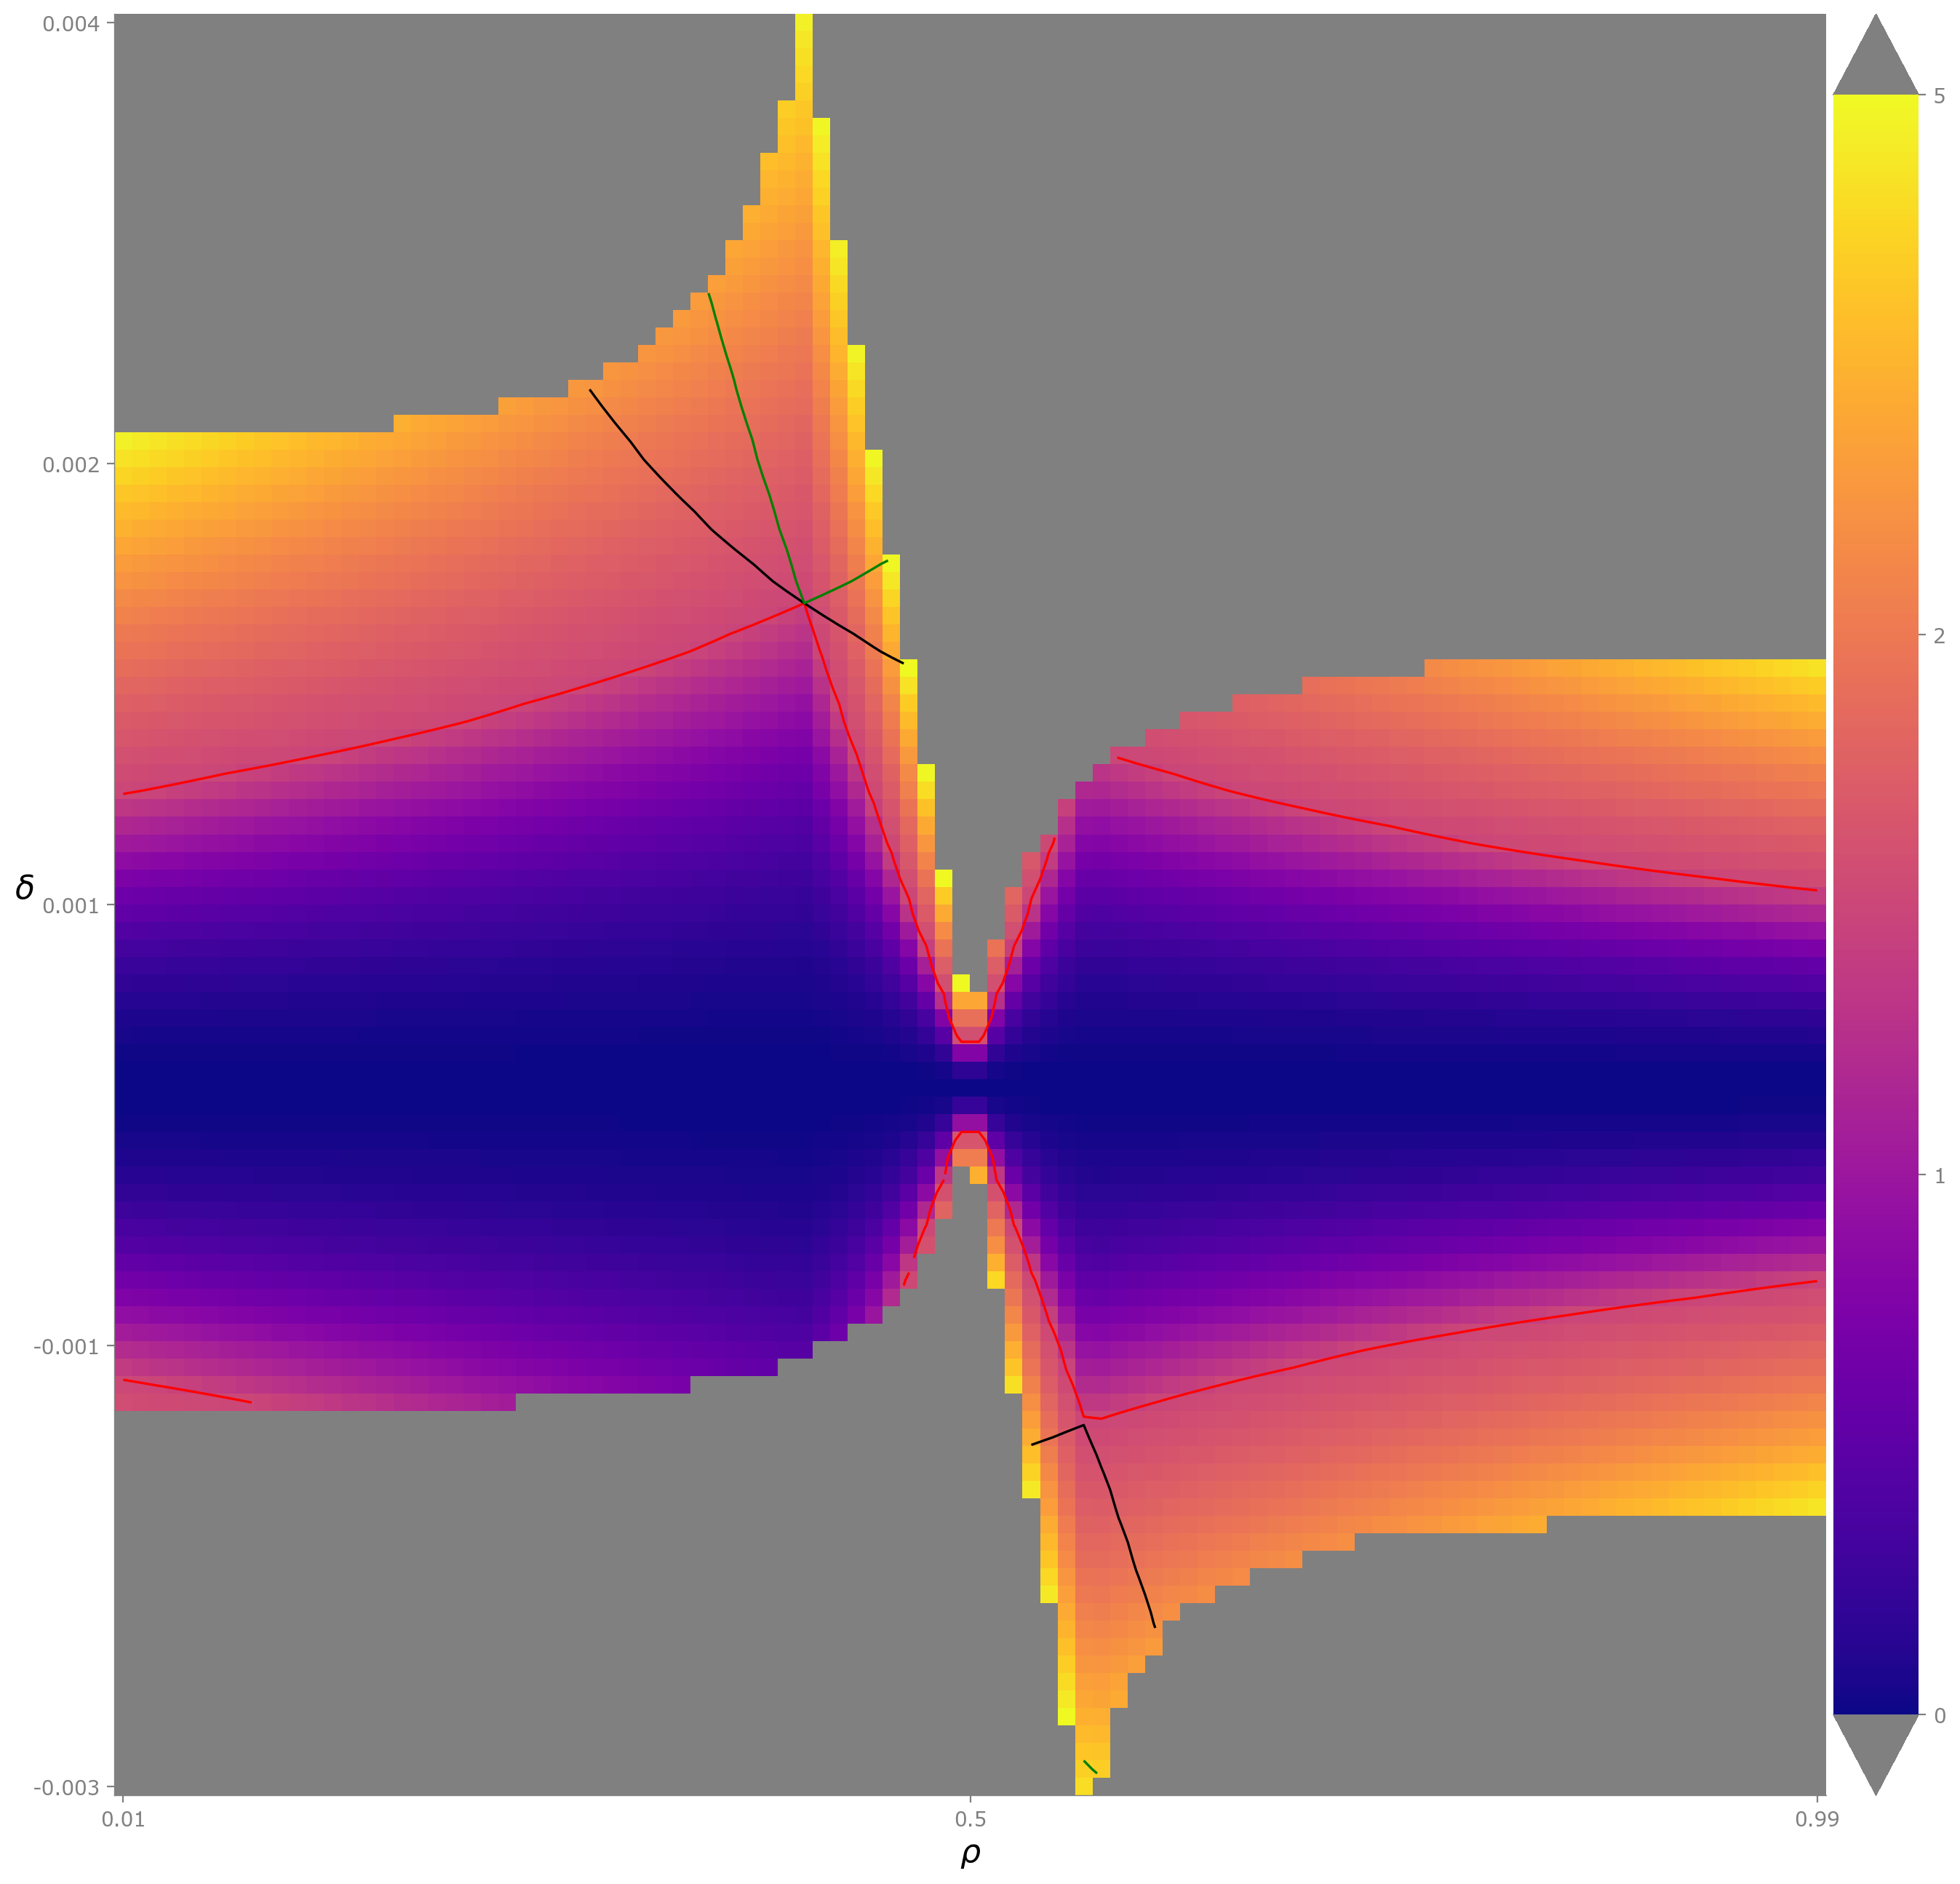

In [39]:
fig = plt.figure(figsize=(16, 16))
widths = [3]
heights = [3]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray', over='gray', bad='gray')
zcenter = 0.5
plot_rhos = np.repeat(rhos, np.size(deltas))
plot_zs = np.tile(deltas, np.size(rhos))
print(np.max(lambdas[:, 1]**2/lambdas[:, 0]))
handels = []
# handels += contour_data(plot_subami, ax, levels=[1e-3], fmt={1e-3: r'AMI$\simeq$0'}, color='gray', inline=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, max_z=max_snr, cmap=cmap, ax=ax, fig=fig, vmin=0, vmax=max_snr, ytickprecision=3, show_ext_color=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

inf
minz=0, maxz=4.998100180499994, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['0', '1', '2', '5']


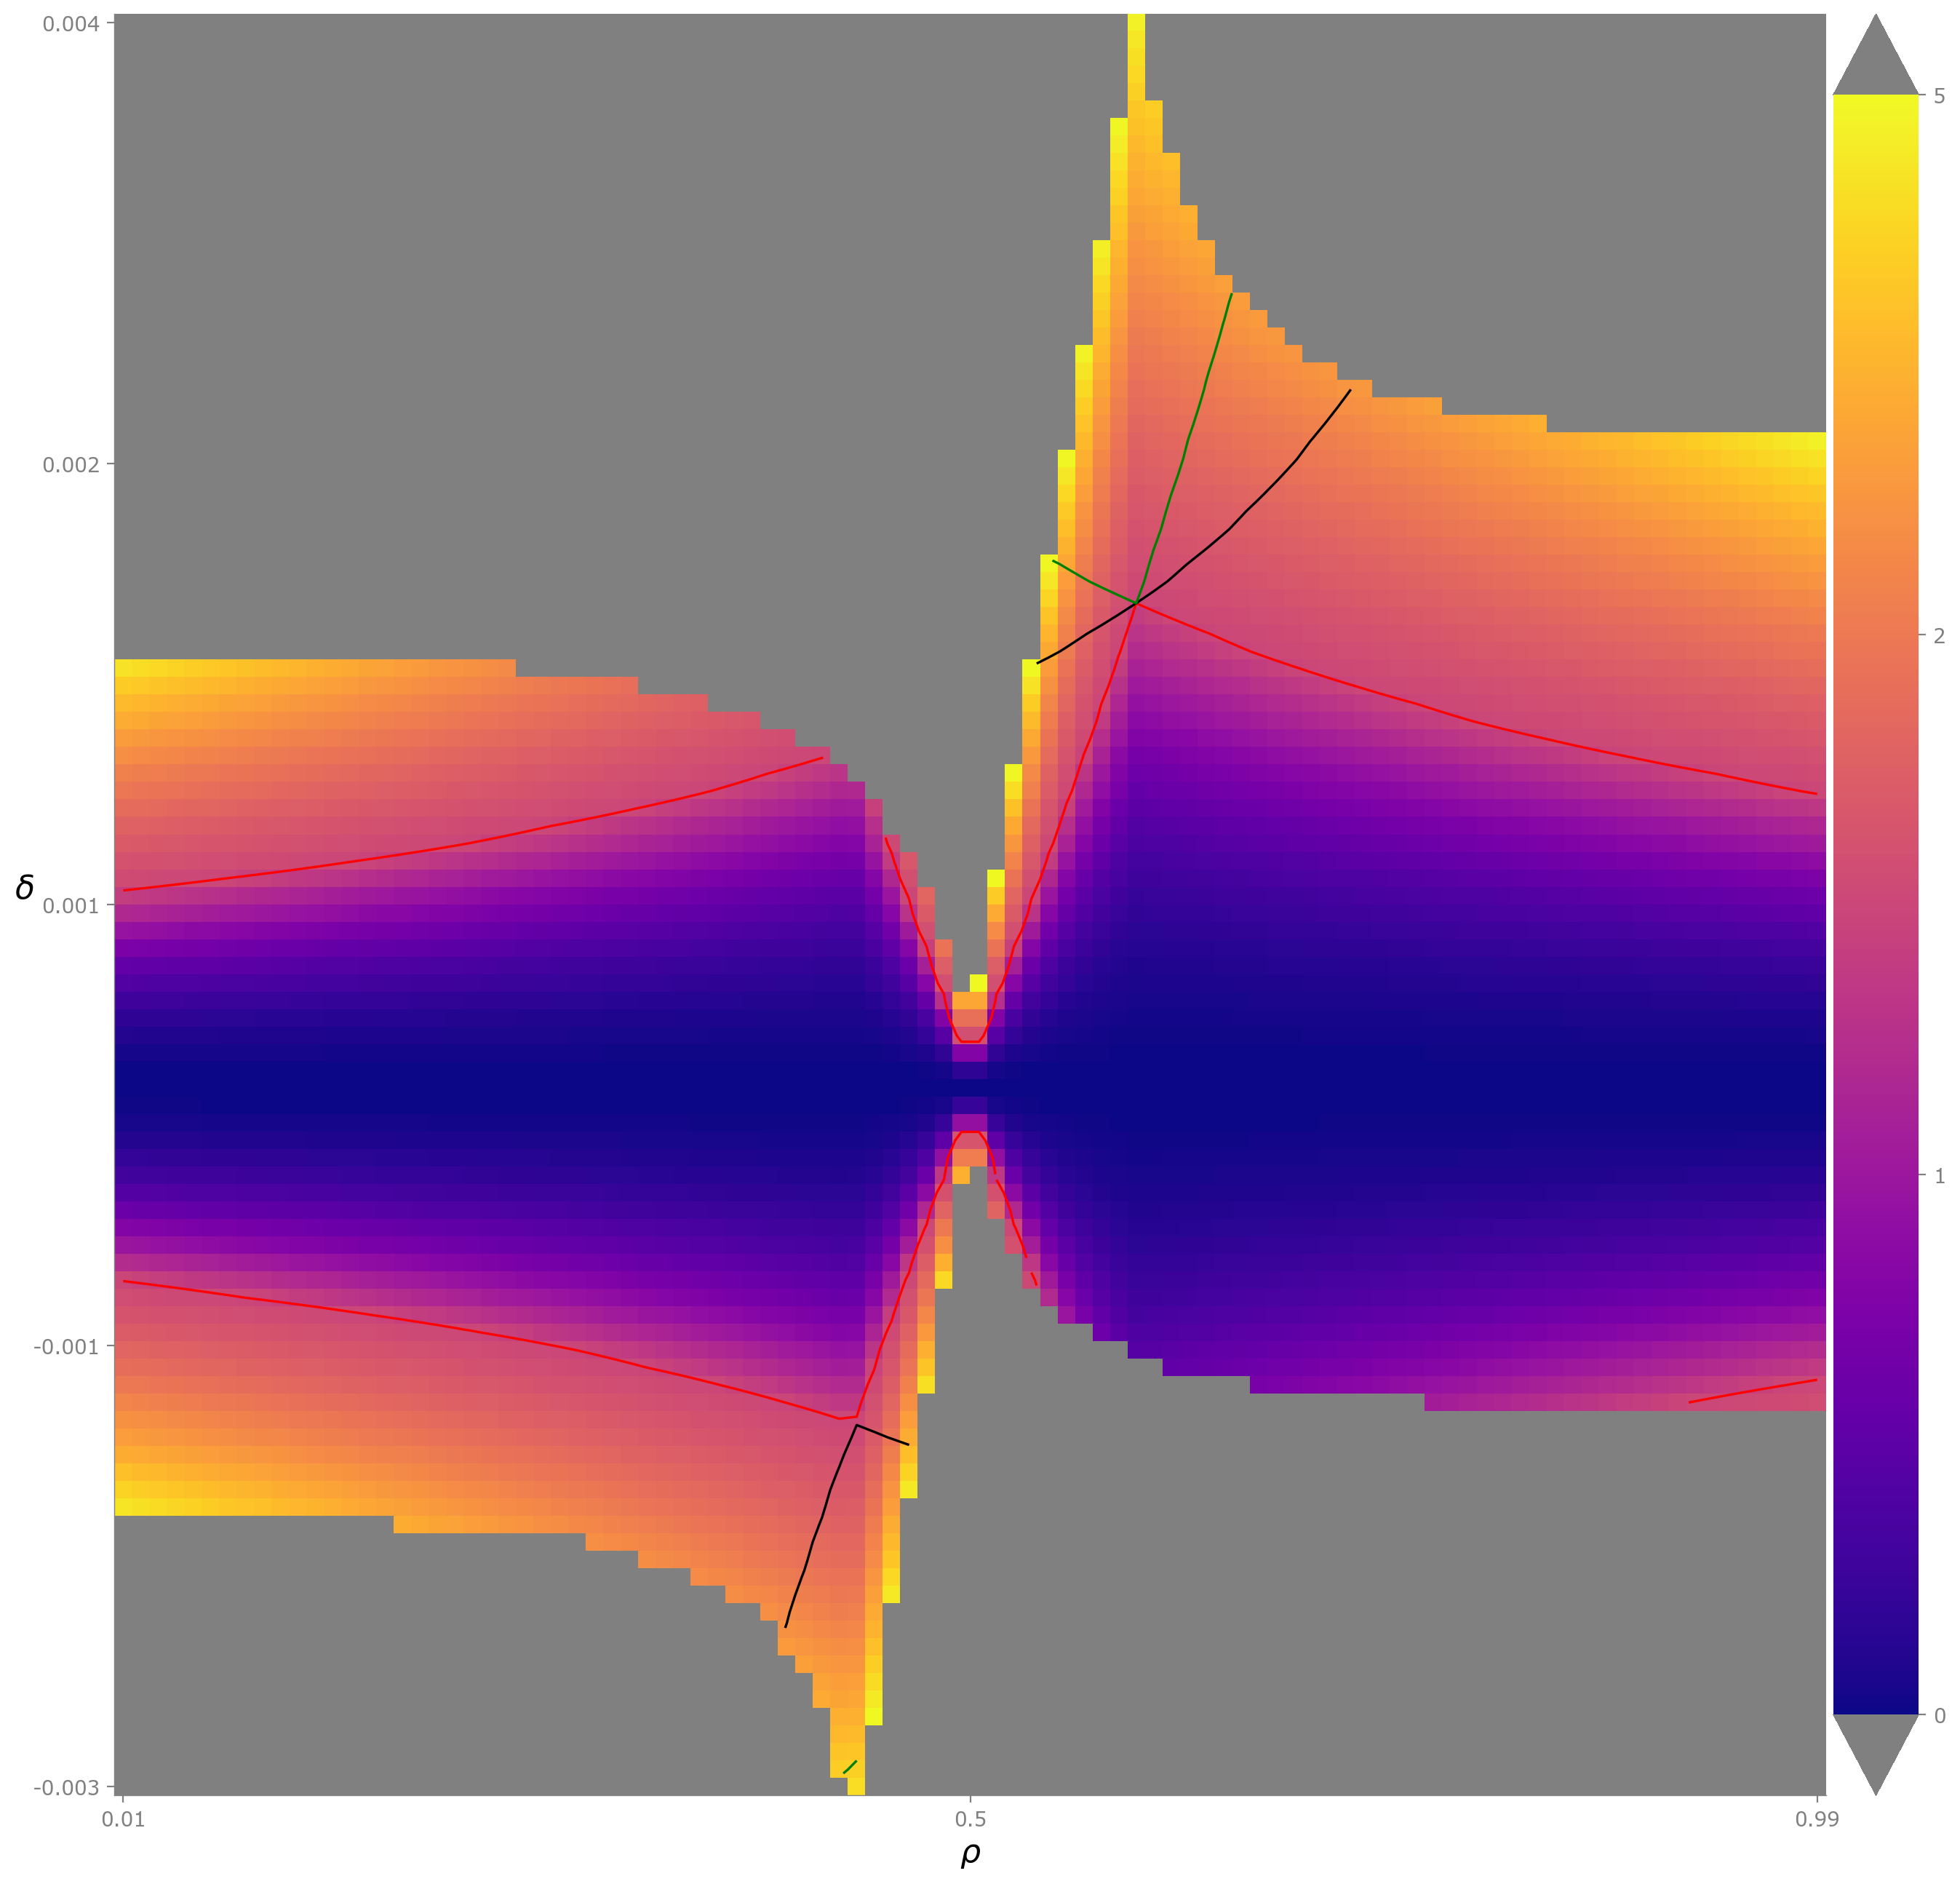

In [42]:
fig = plt.figure(figsize=(16, 16))
widths = [3]
heights = [3]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray', over='gray', bad='gray')
zcenter = 0.5
plot_rhos = np.repeat(rhos, np.size(deltas))
plot_zs = np.tile(deltas, np.size(rhos))
print(np.max(lambdas[:, 1]**2/lambdas[:, 0]))
handels = []
# handels += contour_data(plot_subami, ax, levels=[1e-3], fmt={1e-3: r'AMI$\simeq$0'}, color='gray', inline=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, max_z=max_snr, cmap=cmap, ax=ax, fig=fig, vmin=0, vmax=max_snr, ytickprecision=3, show_ext_color=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

In [ ]:
lambdas_reduce_B = np.zeros((np.size(deltas) * np.size(rhos), 3))
lambdas_reduce_S = np.zeros((np.size(deltas) * np.size(rhos), 4))
expi = 0
for rho in rhos:
    for delta in deltas:
        # Construct 2nd type ps
        pout1 = d / n - (1 / (1 - 2 * rho)) * ((1 - rho) ** 2 / Z_b - rho ** 2 / Z_s) * delta
        pin = pout1 + delta
        pout2 = 2 * d / n - ((1 - rho) / Z_b + rho / Z_s) * delta - pout1
        pout1 = 0 if abs(pout1) < 1e-10 else pout1
        pout2 = 0 if abs(pout2) < 1e-10 else pout2
        pin = 0 if abs(pin) < 1e-10 else pin
        q_B = Z_s + 1
        ps_B = np.zeros((q_B, q_B))
        ps_B = np.array([[pin, pout1, pout2], [pout1, pin, pout2], [pout2, pout2, (pin+(3-1)*pout1)/3]])
        if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
            # print(f'{rho} {delta}')
            lambdas_reduce_B[expi, :] = [-1, 1, 1]
        else:
            P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / 1] * 1)
            Q = n * ps_B
            lambdas_reduce_B[expi, :] = MetaSBM.get_lambdas_general(P, Q)
            # print(f'rho={rho}, delta={delta}, snr of reduce majority communities into 1 community={lambdas_reduce_B[expi, 1]**2/lambdas_reduce_B[expi, 0]}')
        q_S = Z_b + 1
        ps_S = np.zeros((q_S, q_S))
        ps_S = np.array([[(pin+(2-1)*pout1)/2, pout2, pout2, pout2], [pout2, pin, pout1, pout1], [pout2, pout1, pin, pout1], [pout2, pout1, pout1, pin]])
        if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
            # print(f'{rho} {delta}')
            lambdas_reduce_S[expi, :] = [-1, 1, 1, 1]
        else:
            P = np.diag([rho / 1] * 1 + [(1 - rho) / Z_b] * Z_b)
            Q = n * ps_S
            lambdas_reduce_S[expi, :] = MetaSBM.get_lambdas_general(P, Q)
            # print(f'rho={rho}, delta={delta}, snr of reduce majority communities into 1 community={lambdas_reduce_B[expi, 1]**2/lambdas_reduce_B[expi, 0]}')
        expi += 1